In [78]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
import plotly.express as px

## Cálculo de energías en un sistema de 2 cuerpos

### Marzo 10

In [72]:
#2-body system

G = 1 #Canonical units

sistema = [
    dict(m = 1, r = np.array([0, 0, 0]), v = np.array([0, 0, 0])),
    #dict(m = 0.01, r = np.array([1, 0, 0]), v = np.array([0, 1, 0])), # Orbita
    #dict(m = 0.01, r = np.array([1, 0, 0]), v = np.array([0, 3, 0])) # Se escapa
    dict(m = 0.01, r = np.array([1, 0, 0]), v = np.array([0, np.sqrt(2* G), 0])) # Parabolica
]

Energia total

### $ E = U + K $

In [73]:
#Calculate the total mechanical energy of a 2 body systemm

def total_energy(m1,m2, v1, v2, r):
    K = 0.5 * m1 * v1**2 + 0.5 * m2 * v2**2 # kinetic energy
    U = - (G * m1 * m2) / r # potential energy
    E = K + U
    return E, K, U

In [77]:
energia_sistema, K, U = total_energy(sistema[0]['m'], sistema[1]['m'], 
    np.linalg.norm(sistema[0]['v']), np.linalg.norm(sistema[1]['v']), np.linalg.norm(sistema[0]['r'] - sistema[1]['r']))
print(f'Energía total del sistema: {energia_sistema} J')
print(f'Energía cinética total del sistema: {K} J')
print(f'Energía potencial total del sistema: {U} J')

Energía total del sistema: 1.734723475976807e-18 J
Energía cinética total del sistema: 0.010000000000000002 J
Energía potencial total del sistema: -0.01 J


Se prueba si no escapa

In [75]:
ts = np.linspace(0, 10, 100)
rs, vs, rps, vps, cuadraturas = pc.ncuerpos_solucion(sistema, ts)

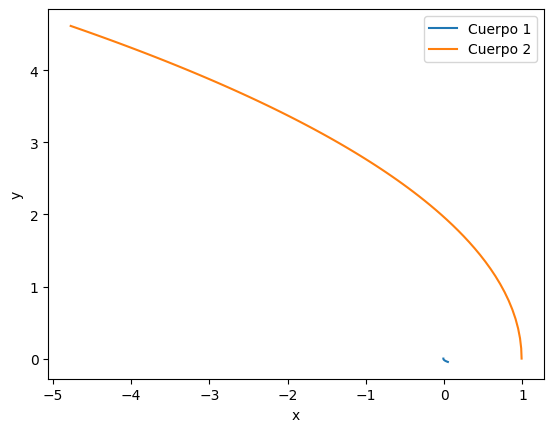

In [76]:
#Check the trajectories

plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [83]:
#3d plot
fig = px.line_3d(x=rps[0,:,0], y=rps[0,:,1], z=rps[0,:,2], title='Trayectoria del Cuerpo 1')
fig.add_scatter3d(x=rps[1,:,0], y=rps[1,:,1], z=rps[1,:,2], mode='lines', name='Cuerpo 2')  
fig.show()


In [85]:
import rebound as rb

In [102]:
sim= rb.Simulation()

sim.add(m=1)
sim.add(m=0.01, x=1, y=0, z=0, vx=0, vy=1, vz=0)

In [108]:
# Integrate

rps = np.zeros((2, 100, 3))
vps = np.zeros((2, 100, 3))
rs = np.zeros((2, 100, 3))
vs = np.zeros((2, 100, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(2):
        rs[j,i] = sim.particles[j].xyz
        vs[j,i] = sim.particles[j].vxyz

        sim.move_to_com()
        rps[j,i] = sim.particles[j].xyz
        vps[j,i] = sim.particles[j].vxyz

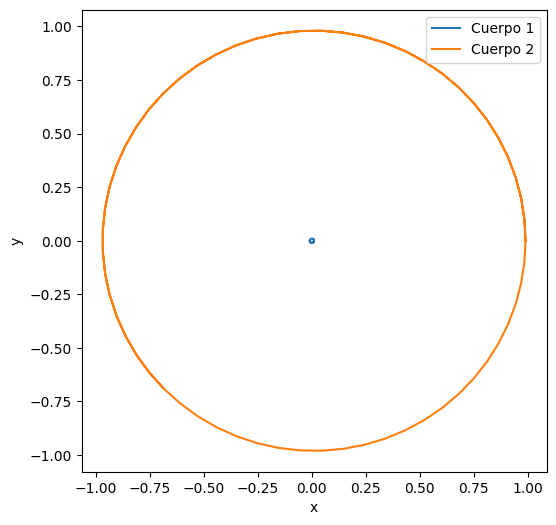

In [110]:
# graph !!

plt.figure(figsize=(6, 6))
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()